# Tiền xử lý NLP cho Tweet (Airline Sentiment)

Dataset: [twitter-airline-sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) - phân tích cảm xúc tweet về các hãng hàng không Mỹ (2015).

Pipeline:
1. **RegEx**: gỡ `@mention`, `#hashtag`, URL, emoji (và một số biểu tượng dạng text).
2. **Chuẩn hóa**: giải mã HTML entity, chữ thường.
3. **Stop words** tiếng Anh + **Lemmatization** (WordNet).

### Import thư viện

In [63]:
import re
import html
from pathlib import Path

import nltk
import pandas as pd
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from collections import Counter
import contractions
import emoji

In [64]:
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

### Download packages NLTK

In [65]:
def _ensure_nltk(pkg: str) -> None:
    try:
        if pkg == "stopwords":
            nltk.data.find("corpora/stopwords")
        elif pkg == "wordnet":
            nltk.data.find("corpora/wordnet")
        elif pkg in ("punkt", "punkt_tab"):
            nltk.data.find(f"tokenizers/{pkg}")
        else:
            nltk.data.find(f"taggers/{pkg}")
    except LookupError:
        nltk.download(pkg)


for _p in ("punkt_tab", "punkt", "stopwords", "wordnet", "averaged_perceptron_tagger_eng", "averaged_perceptron_tagger"):
    _ensure_nltk(_p)

try:
    word_tokenize("ping")
except LookupError:
    nltk.download("punkt")
    nltk.download("punkt_tab")

STOP = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hugdo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 1. Đọc dữ liệu

In [66]:
ROOT = Path("..").resolve()
CSV_PATH = ROOT / "data" / "Tweets.csv"

df = pd.read_csv(CSV_PATH, encoding="utf-8")
print(df.shape)
print(df.columns)
df[["airline_sentiment", "airline", "text"]]

(14640, 15)
Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')


,airline_sentiment,airline,text
0,neutral,Virgin America,@VirginAmerica What @dhepburn said.
1,positive,Virgin America,@VirginAmerica plus you've added commercials t...
2,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...
3,negative,Virgin America,@VirginAmerica it's really aggressive to blast...
4,negative,Virgin America,@VirginAmerica and it's a really big bad thing...
...,...,...,...
14635,positive,American,@AmericanAir thank you we got on a different f...
14636,negative,American,@AmericanAir leaving over 20 minutes Late Flig...
14637,neutral,American,@AmericanAir Please bring American Airlines to...
14638,negative,American,"@AmericanAir you have my money, you change my ..."


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null  str    
 13  tweet_locati

## 2. Làm sạch bằng Regular Expression

- **URL**: `http(s)://...`, `www....`, rút gọn `t.co/...`
- **@mention**: `@handle`
- **#hashtag**: `#tag`
- **Emoji**: các khối Unicode phổ biến + emoticon kiểu `:-)` `:D`

Sau đó **html.unescape** để xử lý `&amp;`, `&lt;`, v.v.

In [68]:
# Regex
RE_URL = re.compile(
    r"https?://\S+|www\.\S+", re.IGNORECASE
)
RE_MENTION = re.compile(r"@\w+")
RE_HASHTAG = re.compile(r"#\w+")

# Emoji => lấy theo dải mã Unicode
RE_EMOJI = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002702-\U000027B0"  # Dingbats
    "\U000024C2-\U0001F251"  # Supplemental
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA70-\U0001FAFF"  # symbols extended-A
    "]+",
    flags=re.UNICODE,
)

# Text emoticon dạng ký tự: =))); :);...
RE_TEXT_EMOTICONS = re.compile(
    r"(?::|;|=)(?:[-']?)(?:\)|\(|D|P|S|\\|/|\[|\]|\||\^|o|O|3|>|<|x|X)(?![\w])"
    r"|(?:\^_|\^_\^|>\.<|T_T|\\o/)",
    re.IGNORECASE,
)

RE_NUMBERS = re.compile(r'\d+')
RE_MULTI_SPACE = re.compile(r"\s+")


def clean_text_regex(raw: str) -> str:
    """Loại URL, mention, hashtag, emoji bằng RegEx; chuẩn hóa khoảng trắng."""
    if not isinstance(raw, str) or not raw.strip():
        return ""
    t = raw.strip()
    t = RE_URL.sub(" ", t)
    t = RE_MENTION.sub(" ", t)
    t = RE_HASHTAG.sub(" ", t)
    t = RE_EMOJI.sub(" ", t)
    t = RE_TEXT_EMOTICONS.sub(" ", t)
    t = html.unescape(t)
    t = RE_MULTI_SPACE.sub(" ", t).strip()
    return t

In [69]:
samples = df["text"].dropna().head(8).tolist()
for s in samples:
    print("---")
    print("Gốc:  ", s[:120], "..." if len(s) > 120 else "")
    print("Sạch: ", clean_text_regex(s)[:120], "..." if len(clean_text_regex(s)) > 120 else "")

---
Gốc:   @VirginAmerica What @dhepburn said. 
Sạch:  What said. 
---
Gốc:   @VirginAmerica plus you've added commercials to the experience... tacky. 
Sạch:  plus you've added commercials to the experience... tacky. 
---
Gốc:   @VirginAmerica I didn't today... Must mean I need to take another trip! 
Sạch:  I didn't today... Must mean I need to take another trip! 
---
Gốc:   @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little re ...
Sạch:  it's really aggressive to blast obnoxious "entertainment" in your guests' faces & they have little recourse 
---
Gốc:   @VirginAmerica and it's a really big bad thing about it 
Sạch:  and it's a really big bad thing about it 
---
Gốc:   @VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing ...
Sạch:  seriously would pay $30 a flight for seats that didn't have this playing. it's really the only bad thing about flying VA 


## 3. Tokenize, bỏ stop words, lemmatize

Ánh xạ POS (Penn Treebank => WordNet) để lemmatize động từ/tính từ chính xác hơn.

In [70]:
def treebank_to_wordnet(tag: str):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def preprocess_pipeline(text: str) -> str:
    """RegEx > token > lower > bỏ stopword > lemma > chuỗi kết quả."""
    cleaned = clean_text_regex(text)
    if not cleaned:
        return ""
    cleaned = cleaned.lower()
    tokens = word_tokenize(cleaned)
    # Chỉ giữ token chữ thuần túy để giảm nhiễu tweet (bỏ số, ký tự đặc biệt, URL đã gỡ)
    # Ví dụ: giữ "flight", bỏ "A321" hoặc "100"; nếu cần giữ từ ngữ chứa apostrophe, hãy mở rộng regex.
    alpha_tokens = [w for w in tokens if re.match(r"^[a-z]+$", w)]
    alpha_tokens = [w for w in alpha_tokens if w not in STOP and len(w) > 1]
    if not alpha_tokens:
        return ""
    tagged = pos_tag(alpha_tokens)
    lemmas = [
        LEMMATIZER.lemmatize(w, treebank_to_wordnet(tag)) for w, tag in tagged
    ]
    return " ".join(lemmas)

In [71]:
df["text_cleaned"] = df["text"].astype(str).map(clean_text_regex)
df["text_preprocessed"] = df["text"].astype(str).map(preprocess_pipeline)

compare = df[["text", "text_cleaned", "text_preprocessed"]].head(12)
compare

,text,text_cleaned,text_preprocessed
0,@VirginAmerica What @dhepburn said.,What said.,say
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experienc...,plus added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,I didn't today... Must mean I need to take ano...,today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""ent...",really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it,really big bad thing
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay $30 a flight for seats tha...,seriously would pay flight seat play really ba...
6,"@VirginAmerica yes, nearly every time I fly VX...","yes, nearly every time I fly VX this “ear worm...",yes nearly every time fly vx ear worm go away
7,@VirginAmerica Really missed a prime opportuni...,Really missed a prime opportunity for Men With...,really missed prime opportunity men without ha...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D","Well, I didn't…but NOW I DO!",well
9,"@VirginAmerica it was amazing, and arrived an ...","it was amazing, and arrived an hour early. You...",amaze arrive hour early good


### Phát triển cho việc dùng SBERT thay vì TF-IDF

In [72]:
# Light-clean text: remove @mentions + URL

RE_SPECIAL_CHARS = re.compile(r"[^a-z\s!?'\"]")
RE_LIGHT_URL = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)

RE_LIGHT_MENTION = re.compile(r'@\w+')
RE_HASHTAG_SYMBOL = re.compile(r"#")
RE_NUMBERS = re.compile(r'\d+')
RE_ELONGATED = re.compile(r'(.)\1+')
RE_MULTI_SPACE = re.compile(r"\s+")

def light_clean_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    
    t = html.unescape(text)
    t = emoji.demojize(t) # "😡" -> ":enraged_face:"
    t = t.lower()
    t = RE_LIGHT_URL.sub(' ', t)
    t = RE_LIGHT_MENTION.sub(' ', t)
    t = RE_HASHTAG_SYMBOL.sub(' ', t)
    t = RE_NUMBERS.sub(' ', t)
    t = RE_ELONGATED.sub(r'\1\1', t)
    t = RE_MULTI_SPACE.sub(' ', t).strip()
    return t

df['light_clean_text'] = df['text'].astype(str).map(light_clean_text)

In [73]:
df[["airline_sentiment", "text", "light_clean_text"]].head(12)

,airline_sentiment,text,light_clean_text
0,neutral,@VirginAmerica What @dhepburn said.,what said.
1,positive,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experienc...
2,neutral,@VirginAmerica I didn't today... Must mean I n...,i didn't today.. must mean i need to take anot...
3,negative,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""ent..."
4,negative,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it
5,negative,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay $ a flight for seats that ...
6,positive,"@VirginAmerica yes, nearly every time I fly VX...","yes, nearly every time i fly vx this “ear worm..."
7,neutral,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...
8,positive,"@virginamerica Well, I didn't…but NOW I DO! :-D","well, i didn't…but now i do! :-d"
9,positive,"@VirginAmerica it was amazing, and arrived an ...","it was amazing, and arrived an hour early. you..."


In [74]:
# Save
out = ROOT / "data" / "Tweets_preprocessed.csv"
df.to_csv(out, index=False, encoding="utf-8")
print("Save to:", out)

Save to: D:\hungdo\Airline-Sentiment\data\Tweets_preprocessed.csv


## 4. Thống kê nhanh

In [39]:
empty_after = (df["text_preprocessed"].str.len() == 0).sum()
empty_ratio = empty_after / len(df)
print(f"Dòng trống sau tiền xử lý: {empty_after} / {len(df)} ({empty_ratio:.1%})")

if empty_ratio > 0.30:
    print("Tỷ lệ dữ liệu trống sau tiền xử lý > 30%")

print("Ví dụ dòng không có kết quả sau tiền xử lý:")
print(df.loc[df["text_preprocessed"] == "", ["text"]].sample(5, random_state=42))



Dòng trống sau tiền xử lý: 42 / 14640 (0.3%)
Ví dụ dòng không có kết quả sau tiền xử lý:
                                                   text
8077  @JetBlue I'm #MakingLoveOutofNothingAtAll on m...
5565  @SouthwestAir @TheEllenShow @Imaginedragons if...
3509                                    @united I have.
8904  @JetBlue @vegecomgirl For me it’s not until 6/15.
1644            @united now this http://t.co/uygeW2Nosr


Tỉ lệ các class (airline_sentiment):
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64


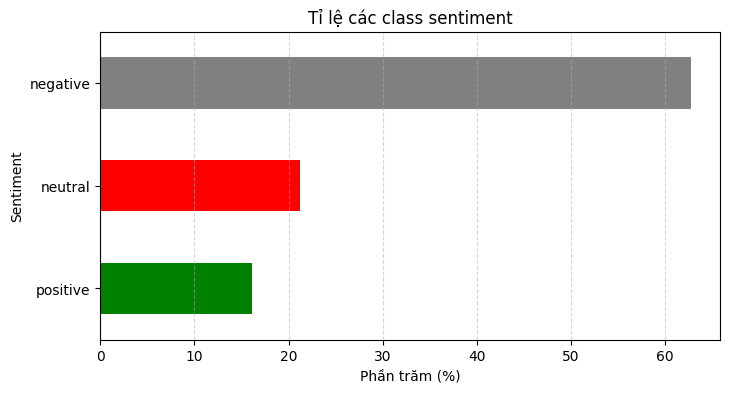

In [40]:
# Thống kê tỉ lệ dữ liệu giữa các class sentiment:
class_ratio = df['airline_sentiment'].value_counts(normalize=True) * 100
print('Tỉ lệ các class (airline_sentiment):')
print(class_ratio.round(2))

plt.figure(figsize=(8, 4))
class_ratio.sort_values().plot(kind='barh', color=['green', 'red', 'gray'])
plt.title('Tỉ lệ các class sentiment')
plt.xlabel('Phần trăm (%)')
plt.ylabel('Sentiment')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### top n-grams

In [41]:

# Top n-grams sau tiền xử lý
def get_ngrams(texts, n=2, top_k=20):
    tokens = []
    for doc in texts:
        if isinstance(doc, str) and doc.strip():
            tokens.extend(doc.split())
    ngrams = Counter([' '.join(tokens[i:i+n]) for i in range(len(tokens)-n+1)])
    return ngrams.most_common(top_k)

for n in (1, 2, 3):
    top_ngrams = get_ngrams(df['text_preprocessed'].fillna(''), n=n, top_k=20)
    print(f"\nTop {n}-grams sau tiền xử lý:")
    for gram, freq in top_ngrams:
        print(f"{gram}: {freq}")



Top 1-grams sau tiền xử lý:
flight: 4671
get: 2103
hour: 1138
thanks: 1068
service: 992
cancel: 963
time: 952
customer: 928
help: 927
delay: 874
call: 774
go: 755
bag: 749
fly: 740
wait: 733
plane: 722
hold: 708
make: 688
need: 683
u: 670

Top 2-grams sau tiền xử lý:
customer service: 564
cancel flightled: 498
flight cancel: 248
late flight: 245
cancel flight: 242
late flightr: 157
fleet fleek: 146
flight delay: 145
flightled flight: 137
flight flight: 136
hold hour: 132
book problem: 124
call back: 113
gate agent: 110
ca get: 106
cancel flighted: 100
flight attendant: 98
get home: 95
flight book: 94
flight get: 88

Top 3-grams sau tiền xử lý:
flight cancel flightled: 163
cancel flightled flight: 134
flight book problem: 74
cancel flight flight: 60
rt fleet fleek: 53
cancel flighted flight: 48
reflight book problem: 46
flight cancel flight: 42
hour late flight: 37
hour late flightr: 36
cancelled flight flight: 33
worst customer service: 29
get cancel flightled: 28
flight cancel flight

## 5. Phát triển: Sentence-BERT + So sánh đánh giá

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [43]:
X = df['light_clean_text'].dropna().tolist()
y = df['airline_sentiment']

In [44]:

# SBERT embedding
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
X_emb = sbert_model.encode(X, show_progress_bar=True, batch_size=128, device="cpu")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6867.16it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 115/115 [01:39<00:00,  1.16it/s]


In [45]:

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.2, random_state=42, stratify=y
)


In [46]:
y_test

2998      neutral
7719     positive
8575     negative
618      negative
11741    negative
           ...   
632      negative
8982      neutral
6329     negative
1179     negative
6553     negative
Name: airline_sentiment, Length: 2928, dtype: str

In [57]:

def eval_and_report(model, name):
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    print(f"=== Results for Training Set: {name} ===")
    print('Macro F1:', f1_score(y_train, y_train_pred, average='macro'))
    print(classification_report(y_train, y_train_pred, digits=4))
    print('Confusion matrix:')
    print(confusion_matrix(y_train, y_train_pred))
    print()
    
    y_test_pred = model.predict(X_test)
    print(f"=== Results for Test Set: {name} ===")
    print('Macro F1:', f1_score(y_test, y_test_pred, average='macro'))
    print(classification_report(y_test, y_test_pred, digits=4))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, y_test_pred))
    print()


In [58]:

# Logistic Regression + SBERT
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

eval_and_report(lr, 'LogisticRegression + SBERT')

# Random Forest + SBERT
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

eval_and_report(rf, 'RandomForest + SBERT')

=== Results for Training Set: LogisticRegression + SBERT ===
Macro F1: 0.7719310780934414
              precision    recall  f1-score   support

    negative     0.9298    0.8100    0.8658      7343
     neutral     0.6086    0.7652    0.6780      2479
    positive     0.7179    0.8349    0.7720      1890

    accuracy                         0.8046     11712
   macro avg     0.7521    0.8034    0.7719     11712
weighted avg     0.8276    0.8046    0.8109     11712

Confusion matrix:
[[5948 1025  370]
 [ 332 1897  250]
 [ 117  195 1578]]

=== Results for Test Set: LogisticRegression + SBERT ===
Macro F1: 0.7312866177494982
              precision    recall  f1-score   support

    negative     0.9192    0.7749    0.8409      1835
     neutral     0.5459    0.7677    0.6381       620
    positive     0.6896    0.7421    0.7149       473

    accuracy                         0.7681      2928
   macro avg     0.7182    0.7616    0.7313      2928
weighted avg     0.8031    0.7681    0.7776

In [52]:
from sklearn.ensemble import VotingClassifier

hybrid_voting = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf)],
    voting='soft',
    weights=[1, 1] # Bạn có thể chỉnh weights=[2, 1] nếu tin tưởng LR hơn
)

# 3. Đánh giá
eval_and_report(hybrid_voting, 'Hybrid (LR + RF) Soft Voting + SBERT')

=== Hybrid (LR + RF) Soft Voting + SBERT ===
Macro F1: 0.7576982269645199
              precision    recall  f1-score   support

    negative     0.8875    0.8812    0.8843      1835
     neutral     0.6439    0.6855    0.6641       620
    positive     0.7466    0.7040    0.7247       473

    accuracy                         0.8111      2928
   macro avg     0.7594    0.7569    0.7577      2928
weighted avg     0.8132    0.8111    0.8119      2928

Confusion matrix:
[[1617  159   59]
 [ 141  425   54]
 [  64   76  333]]



In [53]:
from sklearn.ensemble import StackingClassifier

# 1. Khởi tạo các mô hình cơ sở (Base estimators)
base_models = [
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
]

# 2. Tạo mô hình Meta (Final estimator) 
# Thường dùng LogisticRegression để tổng hợp kết quả một cách mượt mà
hybrid_stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5 # Sử dụng Cross-validation để tránh Overfitting khi training meta-model
)

# 3. Đánh giá
eval_and_report(hybrid_stacking, 'Hybrid (LR + RF) Stacking + SBERT')

=== Hybrid (LR + RF) Stacking + SBERT ===
Macro F1: 0.7570060904747282
              precision    recall  f1-score   support

    negative     0.8792    0.8926    0.8859      1835
     neutral     0.6561    0.6677    0.6619       620
    positive     0.7558    0.6934    0.7233       473

    accuracy                         0.8128      2928
   macro avg     0.7637    0.7513    0.7570      2928
weighted avg     0.8120    0.8128    0.8122      2928

Confusion matrix:
[[1638  140   57]
 [ 157  414   49]
 [  68   77  328]]



In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

# Tạo K-Fold cross validation để giữ nguyên tỉ lệ lớp (rất quan trọng với dữ liệu imbalanced)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================
# 1. Tối ưu Logistic Regression
# ==========================================
print("Đang chạy GridSearchCV cho Logistic Regression...")
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga']
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid=lr_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1, # Dùng tất cả CPU core để chạy nhanh hơn
    verbose=1
)

start_time = time.time()
lr_grid.fit(X_train, y_train)
print(f"Hoàn thành trong: {time.time() - start_time:.2f} giây")
print(f"Tham số LR tốt nhất: {lr_grid.best_params_}")
print(f"F1 Macro (CV) tốt nhất: {lr_grid.best_score_:.4f}\n")

# Đánh giá LR tốt nhất trên tập Test
eval_and_report(lr_grid.best_estimator_, 'Tuned LogisticRegression + SBERT')



Đang chạy GridSearchCV cho Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Hoàn thành trong: 220.90 giây
Tham số LR tốt nhất: {'C': 1, 'solver': 'saga'}
F1 Macro (CV) tốt nhất: 0.7497

=== Results for Training Set: Tuned LogisticRegression + SBERT ===
Macro F1: 0.7723778463193236
              precision    recall  f1-score   support

    negative     0.9298    0.8102    0.8659      7343
     neutral     0.6096    0.7660    0.6789      2479
    positive     0.7181    0.8354    0.7723      1890

    accuracy                         0.8049     11712
   macro avg     0.7525    0.8039    0.7724     11712
weighted avg     0.8279    0.8049    0.8112     11712

Confusion matrix:
[[5949 1022  372]
 [ 332 1899  248]
 [ 117  194 1579]]

=== Results for Test Set: Tuned LogisticRegression + SBERT ===
Macro F1: 0.7318956302097748
              precision    recall  f1-score   support

    negative     0.9205    0.7760    0.8421      1835
     neutral     0.5482    

In [ ]:

# ==========================================
# 2. Tối ưu Random Forest
# ==========================================
print("Đang chạy GridSearchCV cho Random Forest...")
rf_param_grid = {
    'max_depth': [10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
rf_grid.fit(X_train, y_train)
print(f"Hoàn thành trong: {time.time() - start_time:.2f} giây")
print(f"Tham số RF tốt nhất: {rf_grid.best_params_}")
print(f"F1 Macro (CV) tốt nhất: {rf_grid.best_score_:.4f}\n")

# Đánh giá RF tốt nhất trên tập Test
eval_and_report(rf_grid.best_estimator_, 'Tuned RandomForest + SBERT')

Đang chạy GridSearchCV cho Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Hoàn thành trong: 173.39 giây
Tham số LR tốt nhất: {'C': 1, 'solver': 'lbfgs'}
F1 Macro (CV) tốt nhất: 0.7468

=== Results for Training Set: Tuned LogisticRegression + SBERT ===
Macro F1: 0.7719310780934414
              precision    recall  f1-score   support

    negative     0.9298    0.8100    0.8658      7343
     neutral     0.6086    0.7652    0.6780      2479
    positive     0.7179    0.8349    0.7720      1890

    accuracy                         0.8046     11712
   macro avg     0.7521    0.8034    0.7719     11712
weighted avg     0.8276    0.8046    0.8109     11712

Confusion matrix:
[[5948 1025  370]
 [ 332 1897  250]
 [ 117  195 1578]]

=== Results for Test Set: Tuned LogisticRegression + SBERT ===
Macro F1: 0.7312866177494982
              precision    recall  f1-score   support

    negative     0.9192    0.7749    0.8409      1835
     neutral     0.5459    

In [61]:
import numpy as np
from sklearn.metrics import f1_score

# 1. Lấy xác suất dự đoán trên tập Valid/Test
# Lưu ý: Các class trong clf.classes_ thường được sắp xếp theo bảng chữ cái:
# [0] = 'negative', [1] = 'neutral', [2] = 'positive'
y_proba = lr_grid.best_estimator_.predict_proba(X_test)

# 2. Định nghĩa hàm dự đoán với trọng số
def predict_with_weights(proba, w_neutral, w_positive):
    weighted_proba = proba.copy()
    # Nhân thêm trọng số để "thiên vị" các class thiểu số
    weighted_proba[:, 1] *= w_neutral   # Cột 1 là neutral
    weighted_proba[:, 2] *= w_positive  # Cột 2 là positive
    
    # Lấy class có xác suất lớn nhất sau khi đã nhân trọng số
    best_class_idx = np.argmax(weighted_proba, axis=1)
    
    # Map index về lại tên nhãn
    classes = lr_grid.best_estimator_.classes_
    return classes[best_class_idx]

# 3. Tìm kiếm lưới (Grid Search) để tìm trọng số tốt nhất cho Macro F1
best_f1 = 0
best_weights = (1.0, 1.0)

# Duyệt thử các trọng số từ 1.0 đến 2.5
weights_range = np.arange(1.0, 2.5, 0.1)

for w_neu in weights_range:
    for w_pos in weights_range:
        y_pred_custom = predict_with_weights(y_proba, w_neu, w_pos)
        current_f1 = f1_score(y_test, y_pred_custom, average='macro')
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_weights = (w_neu, w_pos)

print(f"Trọng số tối ưu tìm được: Neutral={best_weights[0]:.1f}, Positive={best_weights[1]:.1f}")
print(f"Macro F1 SAU khi chỉnh ngưỡng: {best_f1:.4f}")

# 4. In ra báo cáo chi tiết với trọng số tốt nhất
y_pred_final = predict_with_weights(y_proba, best_weights[0], best_weights[1])
print(classification_report(y_test, y_pred_final, digits=4))

Trọng số tối ưu tìm được: Neutral=1.0, Positive=1.1
Macro F1 SAU khi chỉnh ngưỡng: 0.7338
              precision    recall  f1-score   support

    negative     0.9215    0.7744    0.8416      1835
     neutral     0.5543    0.7661    0.6432       620
    positive     0.6786    0.7590    0.7166       473

    accuracy                         0.7702      2928
   macro avg     0.7181    0.7665    0.7338      2928
weighted avg     0.8045    0.7702    0.7794      2928



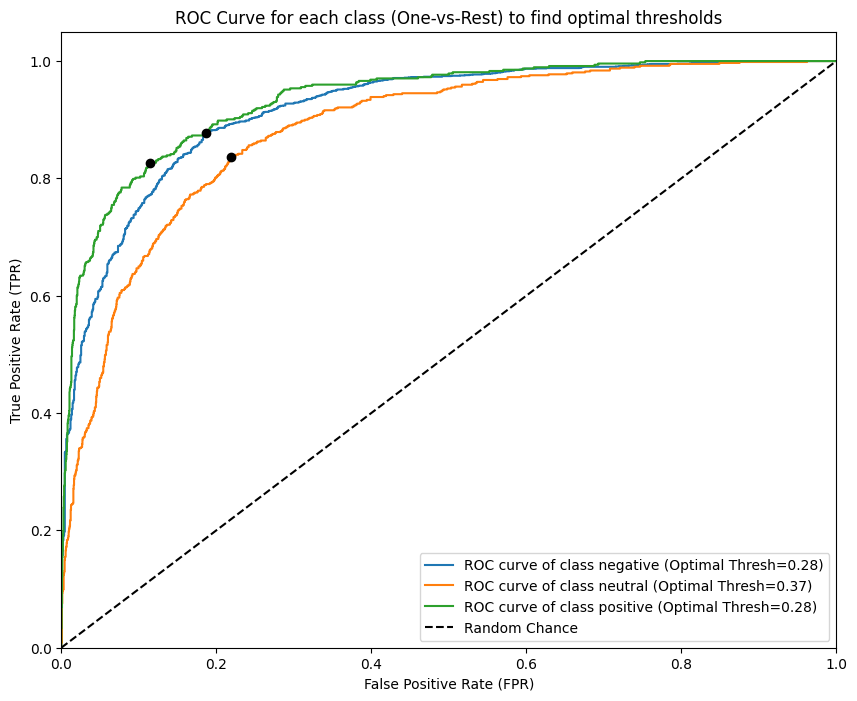

Ngưỡng tối ưu lấy từ ROC Curve: {'negative': np.float64(0.28244590759277344), 'neutral': np.float64(0.36812683939933777), 'positive': np.float64(0.2765403389930725)}

=== KẾT QUẢ SAU KHI ÁP DỤNG NGƯỠNG TỪ ROC ===
Macro F1: 0.7410411707530283
              precision    recall  f1-score   support

    negative     0.9101    0.8109    0.8576      1835
     neutral     0.5957    0.7177    0.6511       620
    positive     0.6667    0.7696    0.7144       473

    accuracy                         0.7845      2928
   macro avg     0.7242    0.7661    0.7410      2928
weighted avg     0.8042    0.7845    0.7908      2928



In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, f1_score, classification_report
from sklearn.preprocessing import label_binarize

# Giả sử mô hình tốt nhất của bạn là lr_grid.best_estimator_
model = lr_grid.best_estimator_
y_proba = model.predict_proba(X_test)
classes = model.classes_  # Thường là ['negative', 'neutral', 'positive']

# 1. Binarize nhãn thực tế (để tính ROC theo kiểu One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

optimal_thresholds = []

# Vẽ biểu đồ trực quan luôn để đưa vào Slide thuyết trình
plt.figure(figsize=(10, 8))

# 2. Tìm ngưỡng tối ưu cho TỪNG CLASS
for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_proba[:, i])
    
    # Tính Youden's J statistic để tìm điểm tối ưu
    J = tpr - fpr
    best_idx = np.argmax(J)
    best_thresh = thresholds[best_idx]
    optimal_thresholds.append(best_thresh)
    
    # Vẽ đường cong ROC
    plt.plot(fpr, tpr, label=f"ROC curve of class {classes[i]} (Optimal Thresh={best_thresh:.2f})")
    # Đánh dấu điểm tối ưu
    plt.scatter(fpr[best_idx], tpr[best_idx], marker='o', color='black', zorder=5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for each class (One-vs-Rest) to find optimal thresholds')
plt.legend(loc="lower right")
plt.show()

print(f"Ngưỡng tối ưu lấy từ ROC Curve: {dict(zip(classes, optimal_thresholds))}")

# 3. Áp dụng ngưỡng tối ưu vào dự đoán
def predict_with_roc_thresholds(proba, thresholds):
    """
    Chia xác suất dự đoán cho ngưỡng tối ưu của class đó.
    Class nào có tỷ lệ vượt ngưỡng cao nhất sẽ được chọn.
    """
    adjusted_proba = proba / thresholds
    best_class_idx = np.argmax(adjusted_proba, axis=1)
    return classes[best_class_idx]

y_pred_roc = predict_with_roc_thresholds(y_proba, optimal_thresholds)

# 4. In kết quả cuối cùng
print("\n=== KẾT QUẢ SAU KHI ÁP DỤNG NGƯỠNG TỪ ROC ===")
print('Macro F1:', f1_score(y_test, y_pred_roc, average='macro'))
print(classification_report(y_test, y_pred_roc, digits=4))

=== LogisticRegression + SBERT ===
Macro F1: 0.6876962193806969
              precision    recall  f1-score   support

    negative     0.9051    0.7324    0.8096      1835
     neutral     0.5072    0.7339    0.5999       620
    positive     0.6099    0.7040    0.6536       473

    accuracy                         0.7281      2928
   macro avg     0.6741    0.7234    0.6877      2928
weighted avg     0.7731    0.7281    0.7400      2928

Confusion matrix:
[[1344  350  141]
 [  93  455   72]
 [  48   92  333]]

=== RandomForest + SBERT ===
Macro F1: 0.5147494904041933
              precision    recall  f1-score   support

    negative     0.6900    0.9864    0.8120      1835
     neutral     0.7786    0.1645    0.2716       620
    positive     0.8563    0.3150    0.4606       473

    accuracy                         0.7039      2928
   macro avg     0.7750    0.4886    0.5147      2928
weighted avg     0.7357    0.7039    0.6408      2928

Confusion matrix:
[[1810   18    7]
 [ 500  102   18]
 [ 313   11  149]]


### Giải thích so sánh
- TF-IDF team khác đã thực hiện và dùng n-gram trực tiếp, model dễ interpret bằng hệ số.
- SBERT tạo embedding dense nắm ngữ nghĩa, giúp xóa mờ sự đa dạng cách diễn đạt, phù hợp tweet ngắn có slang/typo.
- Nếu SBERT + model đạt macro F1 cao hơn (đặc biệt với positive/neutral), là bằng chứng nên dùng embedding mạnh.

# Xử lí imbalance

In [49]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler


def eval_and_report(model, X_tr, y_tr, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_test)
    print(f"=== {name} ===")
    print('Macro F1:', f1_score(y_test, y_pred, average='macro'))
    print(classification_report(y_test, y_pred, digits=4))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)

# 3. Áp dụng các kỹ thuật Resampling lên TẬP TRAIN
print("Đang tiến hành Resampling...")
smote = SMOTE(random_state=42)
adasyn = ADASYN(random_state=42)
rus = RandomUnderSampler(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# ==========================================
# 4. THỰC NGHIỆM VỚI LOGISTIC REGRESSION
# ==========================================
print("\n>>> KẾT QUẢ: LOGISTIC REGRESSION <<<")
# Base model dùng thuật toán phạt trọng số (Class Weighting)
lr_base = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
# Model cho dữ liệu đã resample (Không dùng class_weight)
lr_resampled = LogisticRegression(max_iter=1000, random_state=42)

eval_and_report(lr_base, X_train, y_train, 'LR + SBERT (Base: Class Weighting)')
eval_and_report(lr_resampled, X_train_smote, y_train_smote, 'LR + SBERT + SMOTE')
eval_and_report(lr_resampled, X_train_adasyn, y_train_adasyn, 'LR + SBERT + ADASYN')
eval_and_report(lr_resampled, X_train_rus, y_train_rus, 'LR + SBERT + Random UnderSampler')


# ==========================================
# 5. THỰC NGHIỆM VỚI RANDOM FOREST
# ==========================================
print("\n>>> KẾT QUẢ: RANDOM FOREST <<<")
rf_base = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_resampled = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

eval_and_report(rf_base, X_train, y_train, 'RF + SBERT (Base: Class Weighting)')
eval_and_report(rf_resampled, X_train_smote, y_train_smote, 'RF + SBERT + SMOTE')
eval_and_report(rf_resampled, X_train_adasyn, y_train_adasyn, 'RF + SBERT + ADASYN')
eval_and_report(rf_resampled, X_train_rus, y_train_rus, 'RF + SBERT + Random UnderSampler')

Đang tiến hành Resampling...

>>> KẾT QUẢ: LOGISTIC REGRESSION <<<
=== LR + SBERT (Base: Class Weighting) ===
Macro F1: 0.7312866177494982
              precision    recall  f1-score   support

    negative     0.9192    0.7749    0.8409      1835
     neutral     0.5459    0.7677    0.6381       620
    positive     0.6896    0.7421    0.7149       473

    accuracy                         0.7681      2928
   macro avg     0.7182    0.7616    0.7313      2928
weighted avg     0.8031    0.7681    0.7776      2928

Confusion matrix:
[[1422  314   99]
 [  85  476   59]
 [  40   82  351]]
--------------------------------------------------
=== LR + SBERT + SMOTE ===
Macro F1: 0.7293023118983771
              precision    recall  f1-score   support

    negative     0.9104    0.7864    0.8439      1835
     neutral     0.5436    0.7548    0.6320       620
    positive     0.7054    0.7188    0.7120       473

    accuracy                         0.7688      2928
   macro avg     0.7198    0